# BEE 4750 Homework 3: Dissolved Oxygen and Monte Carlo

**Name**: Sarah Vafiadis, Nathan Rhoads

**ID**: sv439

> **Due Date**
>
> Thursday, 10/16/25, 9:00pm

## Overview

### Instructions

-   Problem 1 asks you to implement a model for dissolved oxygen in a
    river with multiple waste releases and use this to develop a
    strategy to ensure regulatory compliance.

### Load Environment

The following code loads the environment and makes sure all needed
packages are installed. This should be at the start of most Julia
scripts.

In [19]:
import Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()

  Activating project at `c:\Users\sarah\OneDrive\Documents\GitHub\hw3-sarah-nathan-1`


In [20]:
using Random
using Plots
using LaTeXStrings
using Distributions

## Problems (Total: 30 Points)

### Problem 1 (30 points)

A river which flows at 6 km/d is receiving waste discharges from two
sources which are 15 km apart. The oxygen reaeration rate is 0.55
day<sup>-1</sup>, and the decay rates of CBOD and NBOD are are 0.35 and
0.25 day<sup>-1</sup>, respectively. The river’s saturated dissolved
oxygen concentration is 10m g/L.

If the characteristics of the river inflow and waste discharges are
given in <a href="#tbl-river" class="quarto-xref">Table 1</a>, write a
Julia model to compute the dissolved oxygen concentration from the first
wastewater discharge to an arbitrary distance `d` km downstream. Use
your model to compute the minimum dissolved oxygen concentration up to
50 km downstream and how far downriver this maximum occurs.

| Parameter | River Inflow | Waste Stream 1 | Waste Stream 2 |
|:--:|---:|---:|---:|
| Inflow | 100,000 m<sup>3</sup>/d | 10,000 m<sup>3</sup>/d | 15,000 m<sup>3</sup>/d |
| DO Concentration | 7.5 mg/L | 5 mg/L | 5 mg/L |
| CBOD | 5 mg/L | 50 mg/L | 45 mg/L |
| NBOD | 5 mg/L | 35 mg/L | 35 mg/L |

Table 1: River inflow and waste stream characteristics for Problem 1.

### Problem 1.1

Implement the Streeter-Phelps (analytic) solution for the dissolved
oxygen concentration. Plot the dissolved oxygen concentration from the
first waste stream to 50 km downriver. What is the minimum value in
mg/L?

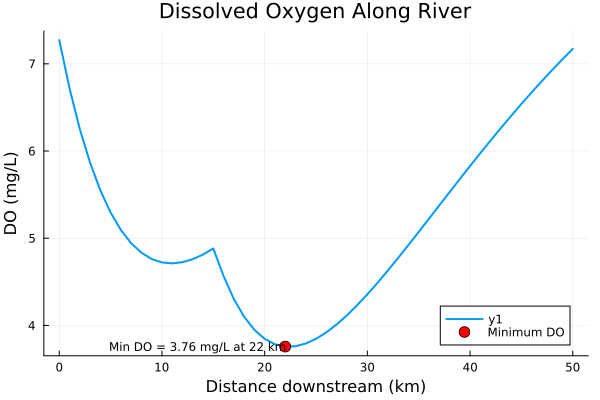

In [50]:
# Parameters
v = 6           # River velocity (km/d) 
Cs = 10         # Saturated DO concentration (mg/L)

ka = 0.55       # Reaeration rate (d^-1)
kc = 0.35       # CBOD decay rate (d^-1)
kn = 0.25       # NBOD decay rate (d^-1)

Qr = 100000     # River inflow (m^3/d)
Q1 = 10000      # Waste stream 1 (m^3/d)
Q2 = 15000      # Waste stream 2 (m^3/d)

DOr = 7.5       # DO concentration in river inflow (mg/L)
DO1 = 5         # DO concentration in waste stream 1 (mg/L)
DO2 = 5         # DO concentration in waste stream 2 (mg/L)

CBODr = 5       # CBOD concentration in river inflow (mg/L)
CBOD1 = 50      # CBOD concentration in waste stream 1 (mg/L)
CBOD2 = 45      # CBOD concentration in waste stream 2 (mg/L)

NBODr = 5       # NBOD concentration in river inflow (mg/L)
NBOD1 = 35      # NBOD concentration in waste stream 1 (mg/L)
NBOD2 = 35      # NBOD concentration in waste stream 2 (mg/L)

# Mixing at point 1
DO_0 = (Qr*DOr + Q1*DO1)  / (Qr+Q1)
CBOD_0 = (Qr*CBODr + Q1*CBOD1)  / (Qr+Q1)
NBOD_0 = (Qr*NBODr + Q1*NBOD1)  / (Qr+Q1)
Q_mix = Qr + Q1

function decay(x,U,C0,B0,N0)
    # x = distance d km downstream
    a1 = exp(-ka*x/U)
    a2 = ((kc/(ka-kc)) * (exp(-kc*x/U) - exp(-ka*x/U)))
    a3 = ((kn/(ka-kn)) * (exp(-kn*x/U) - exp(-ka*x/U)))
    Cx = Cs*(1-a1) + C0*a1 - B0*a2 - N0*a3
    return Cx                                               # DO concentration at distance x
end

# Values at 15 km before mixing
DO_first = decay(15, v, DO_0, CBOD_0, NBOD_0)
CBOD_first = CBOD_0 * exp(-kc * 15 / v)
NBOD_first  = NBOD_0  * exp(-kn * 15 / v)

# Mixing with wastewater stream 2
DO_1 = (Q_mix*DO_first + Q2*DO2)  / (Q_mix + Q2)
NBOD_1 = (Q_mix*NBOD_first + Q2*NBOD2)  / (Q_mix + Q2)
CBOD_1 = (Q_mix*CBOD_first + Q2*CBOD2)  / (Q_mix + Q2)

# Plot for 0 to 50 km
xs = 0:1:50
DO_vals = Float64[]

for i in xs
    if i <= 15
        push!(DO_vals, decay(i, v, DO_0, CBOD_0, NBOD_0))
    else
        push!(DO_vals, decay(i - 15, v, DO_1, CBOD_1, NBOD_1))
    end
end

# plot the DO profile
plot(xs, DO_vals,
     xlabel="Distance downstream (km)",
     ylabel="DO (mg/L)",
     title="Dissolved Oxygen Along River",
     lw=2)

# Identify and plot minimum DO
min_DO, index = findmin(DO_vals)
min_x = xs[index]
scatter!([min_x], [min_DO],
         color=:red,
         markersize=:6,
         label="Minimum DO")

annotate!([(min_x, min_DO, text("Min DO = $(round(min_DO, digits=2)) mg/L at $(min_x) km", :right, 8))])

### Problem 1.2

Implement a numerically-integrated (discretized) solution for the
dissolved oxygen concentration. Using a resolution of 0.5km, conduct a
simulation and plot the results on the same axis as the plot from
Problem 1.1. How has the minimum value changed? What do you attribute
this difference to (be specific about the source of the difference(s) in
terms of the simulation dynamics, not just that one is a numerical
approximation).

### Problem 1.3

Using the analytic model, what is the minimum level of treatment (%
removal of organic waste; assume this is equivalent to the same level of
reduction of the CBOD and NBOD) for waste stream 1 that will ensure that
the dissolved oxygen concentration is in compliance with the 4 mg/L
standard along with a 5% margin of safety, assuming that waste stream 2
remains untreated? How about if only waste stream 2 is treated?

### Problem 1.4

Suppose you are responsible for designing a waste treatment plan for
discharges into the river, with a regulatory mandate to keep the
dissolved oxygen concentration above 4 mg/L. Discuss whether you’d opt
to treat waste stream 2 alone or both waste streams equally. What other
information might you need to make a conclusion, if any?

### Problem 1.5

Suppose that it is known that the DO concentrations at the river inflow
can vary according to a $\text{LogNormal}(2.0, 0.15)$ distribution.
Conduct a Monte Carlo simulation of the DO concentration in the river.
If you treat only waste stream 1 (based on your analysis from Problem
1.3), what is the expected probability and 95% confidence interval that
the river fails to comply with the regulatory standard of 4 mg/L? How
did you decide that your Monte Carlo sample size was sufficiently large?

## References

List any external references consulted, including classmates.